# RideWise · Notebook 06 — Model Interpretability

**Translate the churn model into plain business language at both the global and the individual-rider level.**

---

### What you will learn
- Global drivers via feature importance and logistic coefficients
- Local explanations with SHAP for a single rider
- How to turn model internals into a retention narrative
- Why interpretability is a requirement, not a nicety

### How to read this notebook
Every section follows the same rhythm used throughout the project:
**the business question first**, then the data, then the method, then a
**validation check** that proves the step did what we claimed. Run the cells
top to bottom; nothing depends on hidden state.

---

## 1. The business question

A risk score nobody understands will be ignored. Operations needs to know
**which behaviours drive churn overall**, and for any flagged rider, **why this
person specifically**. This notebook delivers both.

In [1]:
# --- environment setup (run me first) ---
import sys, os
from pathlib import Path

# Make the shared pipeline importable whether you launch from notebooks/ or root
ROOT = Path.cwd()
if (ROOT / "src").exists():
    SRC = ROOT / "src"
elif (ROOT.parent / "src").exists():
    SRC = ROOT.parent / "src"
else:
    raise FileNotFoundError("Could not locate the src/ folder with ridewise_pipeline.py")
sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("Setup OK · pipeline module at:", SRC)

Setup OK · pipeline module at: /home/claude/ridewise/src


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ridewise_pipeline import build_analytics_table, FEATURE_COLUMNS, RANDOM_STATE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
NAVY, ACCENT = "#1F3A5F", "#C8843C"

df = build_analytics_table()
X, y = df[FEATURE_COLUMNS].fillna(0), df["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_tr)
lr = LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5).fit(scaler.transform(X_tr), y_tr)
rf = RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=20,
                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, y_tr)
print("Models ready.")

Models ready.


## 2. Global view — what drives churn across all riders

Two complementary lenses: the Random Forest's feature importance (which features
the trees split on most) and the Logistic Regression coefficients (the
*direction* of each effect — does it raise or lower risk?).

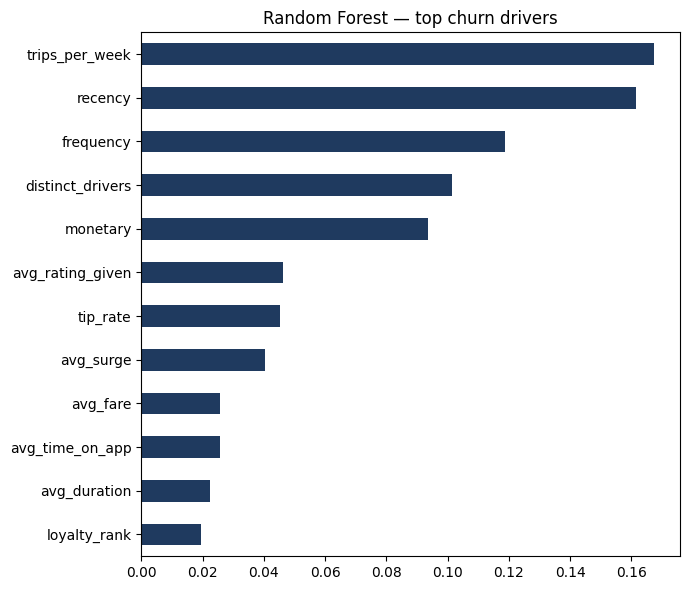

In [3]:
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
plt.figure(figsize=(7, 6)); imp.tail(12).plot.barh(color=NAVY)
plt.title("Random Forest — top churn drivers"); plt.tight_layout(); plt.show()

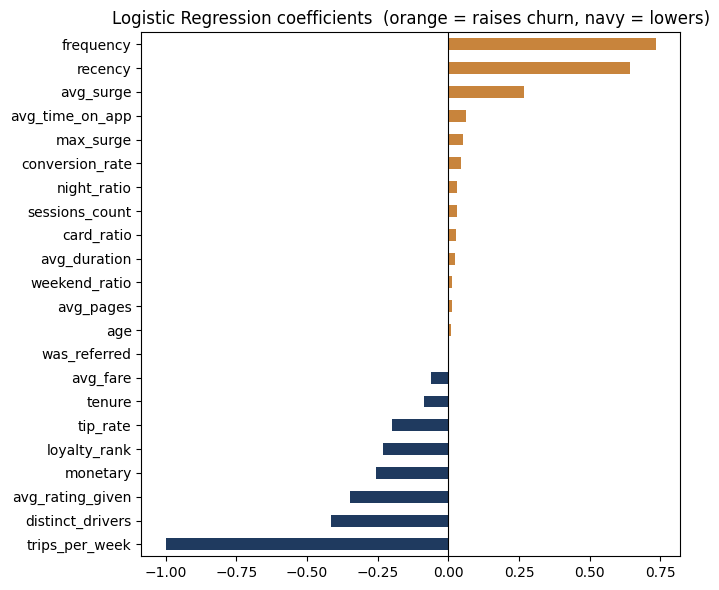

Positive = pushes a rider toward churn; negative = protective.


In [4]:
coef = pd.Series(lr.coef_[0], index=FEATURE_COLUMNS).sort_values()
plt.figure(figsize=(7, 6))
colors = [ACCENT if v > 0 else NAVY for v in coef.values]
coef.plot.barh(color=colors)
plt.title("Logistic Regression coefficients  (orange = raises churn, navy = lowers)")
plt.axvline(0, color="black", lw=0.8); plt.tight_layout(); plt.show()
print("Positive = pushes a rider toward churn; negative = protective.")

**Business translation.** The directions match intuition: longer **recency** and
higher **surge exposure** push riders toward churning, while more **trips per
week**, higher **spend**, better **ratings given** and higher **loyalty** protect
them. That coherence is itself a validation — the model learned sensible things.

## 3. Local view — why *this* rider was flagged (SHAP)

SHAP attributes a single prediction to its individual features, so an operator
can read a one-line reason for any flagged rider.

In [5]:
import shap
# TreeExplainer is fast and exact for tree models
explainer = shap.TreeExplainer(rf)
sample = X_te.iloc[:500]
shap_values = explainer.shap_values(sample)
# For binary RF, take the positive-class contributions
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1] if shap_values.ndim == 3 else shap_values
print("SHAP values computed for", sample.shape[0], "riders.")

SHAP values computed for 500 riders.


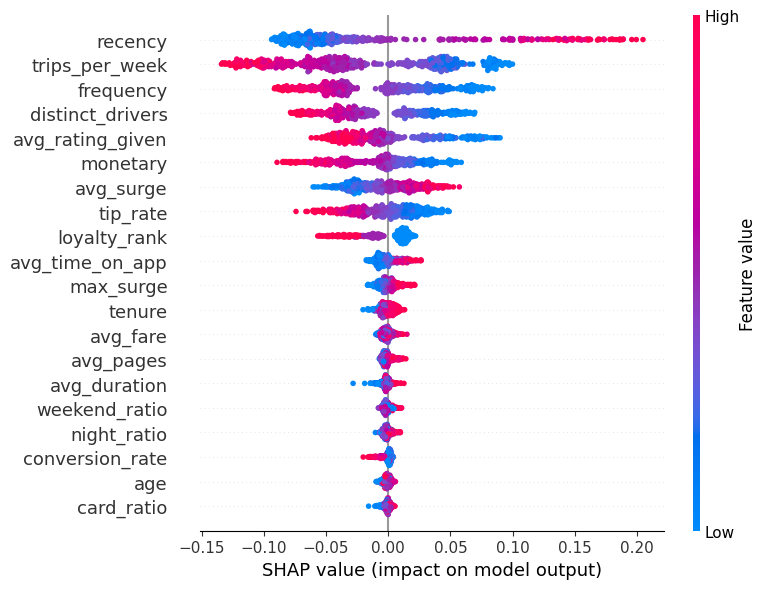

In [6]:
shap.summary_plot(sv, sample, feature_names=FEATURE_COLUMNS, show=False, plot_size=(8, 6))
plt.tight_layout(); plt.show()

**Worked example — explain one rider.** Pick a high-risk rider and read the
features pushing their score up versus down.

In [7]:
probs = rf.predict_proba(X_te)[:, 1]
hi = int(np.argmax(probs[:500]))  # highest-risk rider in our SHAP sample
contrib = pd.Series(sv[hi], index=FEATURE_COLUMNS).sort_values()
print(f"Rider index {hi}: predicted churn probability = {probs[hi]:.2f}\n")
print("Top 3 reasons risk is HIGH:")
for f, v in contrib.tail(3)[::-1].items():
    print(f"   {f:18s}  (+{v:.3f})   value={X_te.iloc[hi][f]:.2f}")
print("\nTop 3 factors holding risk DOWN:")
for f, v in contrib.head(3).items():
    print(f"   {f:18s}  ({v:.3f})   value={X_te.iloc[hi][f]:.2f}")

Rider index 439: predicted churn probability = 0.92

Top 3 reasons risk is HIGH:
   recency             (+0.129)   value=56.00
   trips_per_week      (+0.087)   value=0.19
   frequency           (+0.068)   value=9.00

Top 3 factors holding risk DOWN:
   loyalty_rank        (-0.005)   value=1.00
   tip_rate            (-0.002)   value=0.03
   sessions_count      (-0.001)   value=5.00


## 4. Summary

- Global drivers are coherent and match domain intuition (a validation in itself).
- SHAP gives a per-rider reason an operator can read in one line.
- Together these make the score **trustworthy and actionable**, not a black box.

**Next:** Notebook 07 turns probabilities into a concrete retention list.